In [3]:
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import os

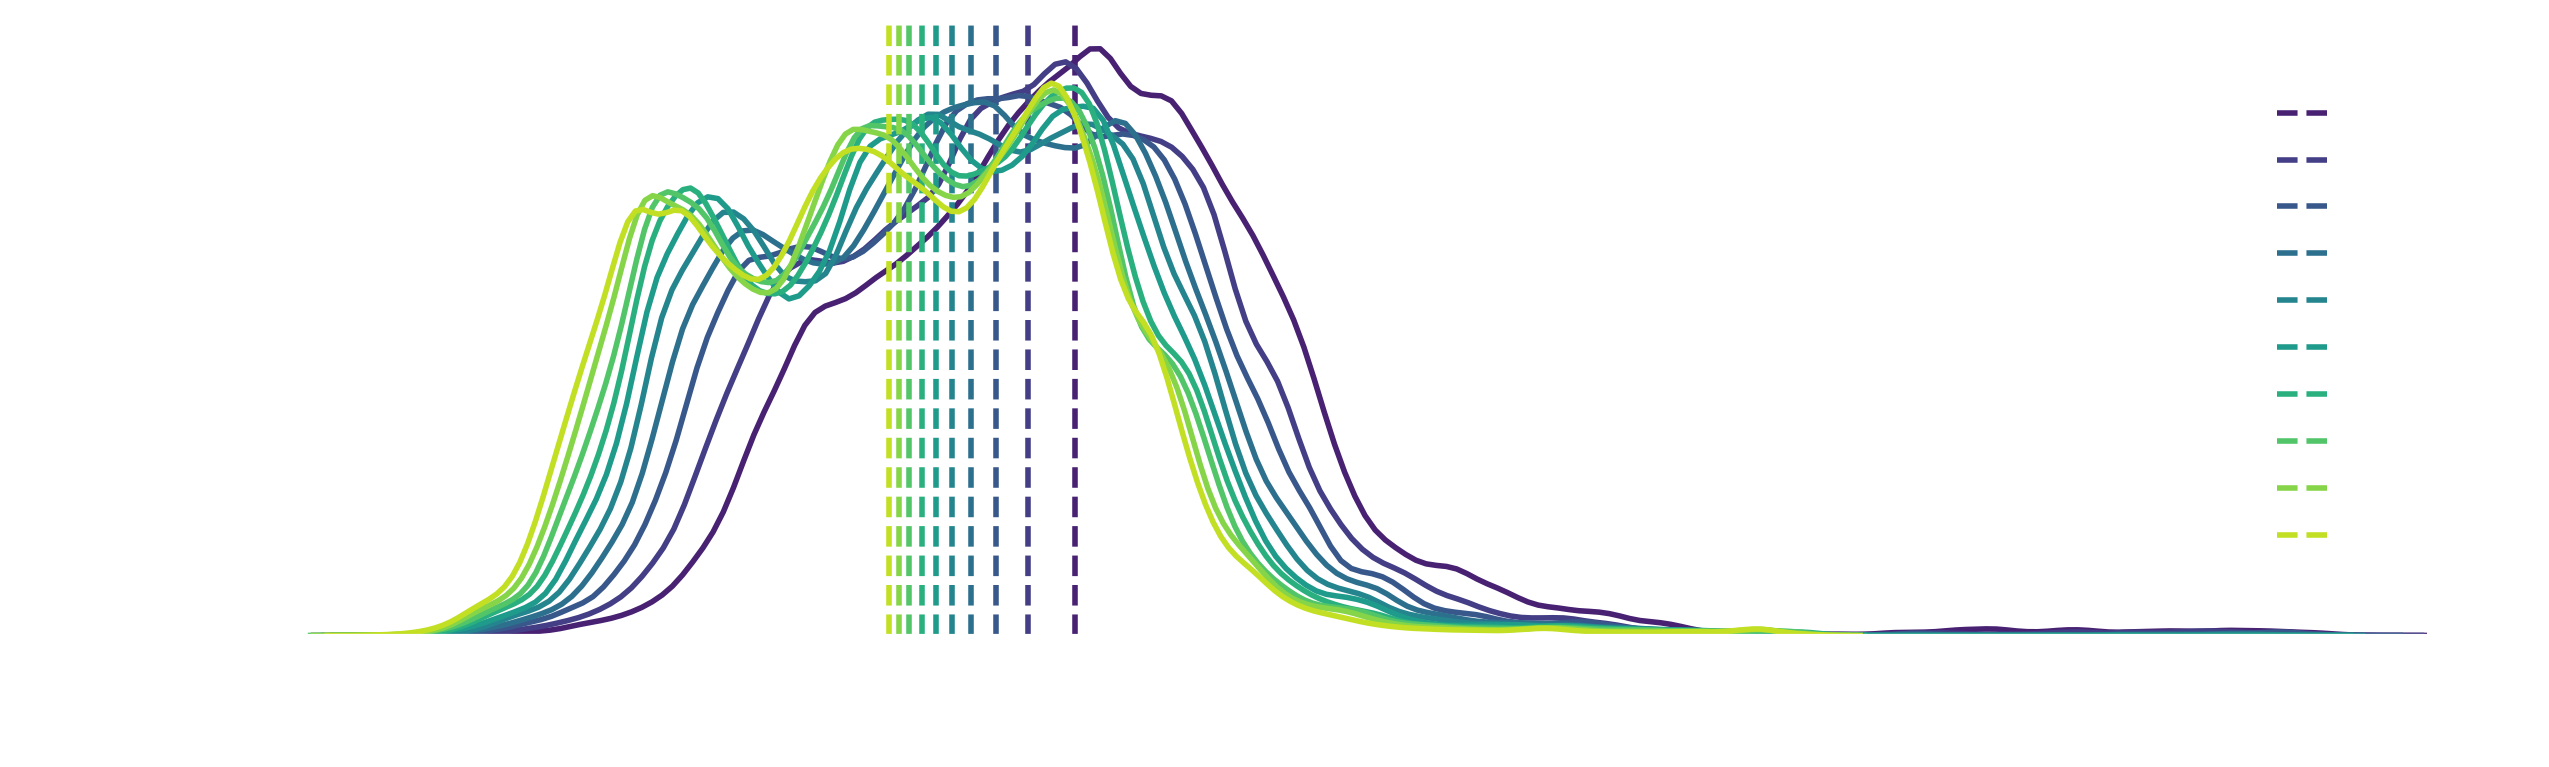

In [33]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

folder_path = "ISMRM_GT_HCP/Anomaly_images_median"
nifti_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.nii.gz')])

colors = sns.color_palette('viridis', n_colors=len(nifti_files))
fig, ax = plt.subplots(figsize=(15, 4), dpi=200)
fig.patch.set_alpha(0) 
for i, file_name in enumerate(nifti_files):
    file_path = os.path.join(folder_path, file_name)
    img = nib.load(file_path)
    data = img.get_fdata()
    non_zero_data = data[data != 0]
    
    sns.kdeplot(non_zero_data, color=colors[i], common_norm=False, ax=ax, linewidth=2)
    ax.axvline(np.mean(non_zero_data), color=colors[i], linestyle='dashed', linewidth=2, label=f'param {i} ')

legend = ax.legend(title="Mean")

legend_title = legend.get_title()
legend_title.set_fontsize('14')
legend_title.set_color('white')
legend.set_alpha(0)
legend.set_frame_on(False)
for text in legend.texts:
    text.set_color('white')
    text.set_fontsize(12)

ax.set_xlabel('Structural anomaly', color='white', fontsize=16)
ax.set_ylabel('Density', color='white', fontsize=16)

ax.tick_params(axis='x', colors='white', labelsize=14)
ax.tick_params(axis='y', colors='white', labelsize=14)

ax.spines['bottom'].set_color('white')
ax.spines['top'].set_color('white')
ax.spines['right'].set_color('white')
ax.spines['left'].set_color('white')

plt.savefig("kde_plots.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [37]:
non_zero_data.std()

51.60304519332098

In [38]:
for i, file_name in enumerate(nifti_files):
    file_path = os.path.join(folder_path, file_name)
    img = nib.load(file_path)
    data = img.get_fdata()
    non_zero_data = data[data != 0]
    print(non_zero_data.mean())
    print(non_zero_data.std())

219.09462548257926
54.581731513435805
206.66178868169405
52.50625971321679
198.37568524048464
51.887529179857424
191.87731268876988
51.08203879594794
186.84986867567605
51.2184907956553
182.63618409651804
51.20110003789645
178.83518610710604
51.13838760830961
175.65350350867274
51.32630697890036
172.94281039744223
51.49142925706796
170.41501647236655
51.60304519332098
